[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bsheese/225/blob/main/08_data_cleaning/08_2_Missing_Data.ipynb)

# 08.2: Missing Data

So far this module has used the pre-cleaned course Titanic CSV, which has no missing values. That is unusual. Most real datasets have gaps, and the Titanic passenger list is a good example: historical records were incomplete, so ages were not recorded for many passengers and deck assignments are missing for most of them.

To work with genuine missing data, this notebook uses seaborn's built-in Titanic dataset, which has 891 rows and reflects those real gaps. The techniques you learn here apply to any dataset with missing values. Let's load it.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# The seaborn Titanic dataset has genuine missing values in age and deck
df = sns.load_dataset("titanic")
df = df[["survived", "pclass", "sex", "age", "fare", "deck", "embarked"]].copy()
df.head()

,survived,pclass,sex,age,fare,deck,embarked
0,0,3,male,22.0,7.2500,NaN,S
1,1,1,female,38.0,71.2833,C,C
2,1,3,female,26.0,7.9250,NaN,S
3,1,1,female,35.0,53.1000,C,S
4,0,3,male,35.0,8.0500,NaN,S


891 rows, 7 columns: survived, pclass, sex, age, fare, deck, and embarked. Notice the `NaN` values already visible in the `deck` column of the first five rows: those are genuine missing values from incomplete historical records. Before deciding how to handle them, you need to know how many there are and which columns are affected.

## Step 1: How much is missing?

Before taking any action, measure the scale of the problem. `isnull().sum()` counts nulls per column. Expressing that as a percentage of total rows gives you a sense of how much data you stand to lose.

In [2]:
n = len(df)
missing = df.isnull().sum()
pct = (missing / n * 100).round(1)
summary = pd.DataFrame({"missing": missing, "pct_missing": pct})
summary[summary["missing"] > 0]

,missing,pct_missing
age,177,19.9
deck,688,77.2
embarked,2,0.2


Three columns have missing values, but at very different scales. `embarked` is missing only 2 values out of 891, which is a negligible amount. `age` is missing about 20%, which is large enough to matter in any analysis that uses age. `deck` is missing 77% of its values, which is so extreme that the non-missing rows may not be representative of the full passenger population at all.

The right strategy is different for each column, and that is exactly why diagnosis comes before action.

## Step 2: Where is it missing?

A heatmap of the null indicators reveals whether missing values are scattered randomly or clustered in certain rows. Clustered missingness often signals a data source problem or a subgroup that was recorded differently.

Text(0.5, 27.444444444444436, 'Passengers (each column is one passenger row)')

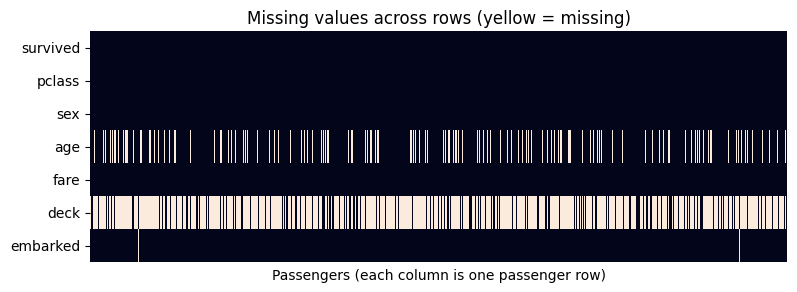

In [3]:
fig, ax = plt.subplots(figsize=(9, 3))
sns.heatmap(
    df.isnull().T,
    cbar=False,
    yticklabels=df.columns,
    xticklabels=False,
    ax=ax
)
ax.set_title("Missing values across rows (yellow = missing)")
ax.set_xlabel("Passengers (each column is one passenger row)")

The `deck` row is almost entirely yellow, confirming the 77% missingness. The `age` row shows scattered gaps throughout the dataset, with no obvious cluster, consistent with ages simply not being recorded for certain passengers rather than a systematic data entry problem. The two `embarked` gaps are nearly invisible at this scale.

> When missing values form a block (all clustered in one region of the heatmap), it often means the data was concatenated from multiple sources and one source did not have that field. Imputing without investigating can silently assign invented values to an entire subgroup.

## Step 3: Is the missingness related to the outcome?

The most important diagnostic question is whether the missing values are related to other variables. If passengers with missing ages had a different survival rate than those with recorded ages, then dropping the age-missing rows would systematically bias the survival analysis.

In [4]:
df["age_missing"] = df["age"].isnull()
comparison = df.groupby("age_missing")["survived"].mean()
comparison.index = ["age recorded", "age missing"]
comparison.round(3)

age recorded    0.406
age missing     0.294
Name: survived, dtype: float64

The survival rates are similar between the two groups. That makes the missing age data more consistent with random missingness rather than a systematic difference between passengers. This is not proof that dropping is safe, but it is a useful sanity check before committing to a strategy.

We have finished using `age_missing` as a diagnostic flag. Remove it before moving on so it does not appear in subsequent outputs.

In [5]:
df = df.drop(columns=["age_missing"])

## Dropping strategies

Module 06 showed `dropna()` in its simplest form: drop any row that has at least one null. That is the default, and it is often too aggressive when only a handful of columns have missing values. pandas gives you finer control.

### `dropna(thresh=)`: keep rows with enough data

The `thresh=` argument keeps rows that have at least a specified number of non-null values. This is useful when your dataset has several sparse columns and you want to keep rows that are mostly complete, even if a few fields are blank.

In [6]:
print("Shape before any dropna:", df.shape)

# Default: drop any row with any null
df_strict = df.dropna()
print("After dropna() default:", df_strict.shape)

# Keep rows that have at least 5 non-null values (out of 7 columns)
df_thresh = df.dropna(thresh=5)
print("After dropna(thresh=5):", df_thresh.shape)

Shape before any dropna: (891, 7)
After dropna() default: (182, 7)
After dropna(thresh=5): (891, 7)


The default `dropna()` cuts the dataset from 891 to 182 rows because `deck` alone is missing in 688 rows. `thresh=5` recovers most of those rows by saying "keep the row as long as at least 5 of the 7 columns are filled in." The rows that remain after `thresh=5` will still have some nulls, but they have enough information to be useful.

The right threshold depends on what your analysis needs. If you are only analyzing `age`, `survived`, and `pclass`, those three columns being non-null is all you need, not all seven. In that case, `dropna(subset=["age", "survived", "pclass"])` is more precise than any general threshold.

### `dropna(how="all")`: drop only entirely-null rows

When a DataFrame is assembled from multiple sources, or when a data export adds blank separator rows, you may end up with rows where every single value is null. The `how="all"` argument drops those rows while leaving all partially-filled rows untouched.

In [ ]:
# Add a completely null row to demonstrate
df_with_empty = df.head(5).copy()
df_with_empty.loc[5] = [None] * len(df_with_empty.columns)
print("Rows before:", len(df_with_empty))
print(df_with_empty.tail(3))

df_cleaned = df_with_empty.dropna(how="all")
print("\nRows after dropna(how='all'):", len(df_cleaned))

`how="all"` removed the single completely-null row and left all the partially-null rows intact. This is a good first step in any cleaning pipeline: clear out the empty rows before doing anything more sophisticated.

## Filling strategies

Dropping rows discards data. Filling is a choice to estimate what the missing value probably was. The right filling strategy depends on the structure of the data.

### Forward-fill and backward-fill

When data has a meaningful order (time series, sensor readings, log entries), a missing value can reasonably be replaced with the value immediately before or after it. `ffill()` carries the most recent non-null value forward; `bfill()` carries the next non-null value backward.

Imagine a temperature sensor that records a reading every hour but occasionally fails. The last known reading is probably a good estimate for the gap.

In [8]:
# Simulate an ordered sequence with gaps
readings = pd.Series([22.0, None, None, 35.0, None, 41.0, 28.0], name="temp")

result = pd.DataFrame({
    "original": readings,
    "ffill": readings.ffill(),
    "bfill": readings.bfill()
})
result

,original,ffill,bfill
0,22.0,22.0,22.0
1,NaN,22.0,35.0
2,NaN,22.0,35.0
3,35.0,35.0,35.0
4,NaN,35.0,41.0
5,41.0,41.0,41.0
6,28.0,28.0,28.0


Forward-fill replaced the gaps at positions 1 and 2 with 22.0 (the previous known value), then replaced the gap at position 4 with 35.0. Backward-fill worked in the other direction: the gap at position 1 received 35.0 (the next known value), and the gap at position 4 received 41.0.

Neither approach is right for Titanic ages, because the rows are not meaningfully ordered by any time-like dimension. Forward-fill is most appropriate when the order matters: measurements over time, steps in a process, or readings along a route.

### `interpolate()`: fill numeric gaps smoothly

Interpolation estimates missing values by fitting a line through the known values on either side of the gap. For data that changes gradually and continuously, this is more realistic than carrying a constant forward.

In [9]:
# Monthly average temperatures with two months missing
temps = pd.Series(
    [32.0, None, None, 55.0, 67.0, 75.0, None, 73.0, 65.0, 50.0, 40.0, 34.0],
    index=range(1, 13),
    name="temp_F"
)

pd.DataFrame({
    "original": temps,
    "ffill": temps.ffill(),
    "interpolate": temps.interpolate().round(1)
})

,original,ffill,interpolate
1,32.0,32.0,32.0
2,NaN,32.0,39.7
3,NaN,32.0,47.3
4,55.0,55.0,55.0
5,67.0,67.0,67.0
6,75.0,75.0,75.0
7,NaN,75.0,74.0
8,73.0,73.0,73.0
9,65.0,65.0,65.0
10,50.0,50.0,50.0


For months 2 and 3 (February and March), forward-fill holds 32.0 in both because that was the last known value. Interpolation draws a line from January (32.0) to April (55.0) and estimates February at about 39.7 and March at about 47.3. For temperature data that changes gradually with the seasons, the interpolated values are clearly more realistic.

`interpolate()` accepts a `method=` argument: `"linear"` (the default), `"polynomial"`, or `"time"` for datetime-indexed data. Linear interpolation is the right choice for most cleaning tasks.

## Applying a strategy to the Titanic `age` column

With the diagnostics done, we can make an informed choice for `age`. The gaps appear scattered, and passengers with missing ages have a similar survival rate to those with recorded ages. The simplest defensible choice is to fill with the median age, which is more robust to outliers than the mean.

In [10]:
median_age = df["age"].median()
print(f"Median age: {median_age}")

df["age"] = df["age"].fillna(median_age)
print(f"Null count after fill: {df['age'].isnull().sum()}")

Median age: 28.0
Null count after fill: 0


Zero nulls remaining. Any subsequent analysis using age will now include all 891 passengers. The trade-off is that 177 passengers now share the same imputed age, which will slightly compress any age-related patterns. A research paper would document this choice explicitly; for an exploratory analysis, median fill is a reasonable default.

> A more sophisticated approach would fill by group: compute the median age separately for each combination of class and sex, then fill each missing age with the median for its specific subgroup. You could do this with `df.groupby(["pclass", "sex"])["age"].transform("median")` and use the result as the fill source. This preserves the known relationship between class, sex, and age. For now, the simple median fill illustrates the concept.

## A missing-data checklist

Before dropping or filling any null values, work through these four questions in order:

1. How much is missing? (`isnull().sum()` and percentage)
2. Where is it missing? (heatmap of `df.isnull().T`)
3. Is the missingness related to the outcome? (compare group means)
4. What is the right strategy? Drop if the data is largely empty or the count is tiny; fill if you want to preserve rows; interpolate for ordered numeric sequences.

## What's next

Missing values are one category of messiness. Notebook 08.3 covers a second: type problems. What happens when a numeric column is stored as text, when a boolean is encoded as `"yes"`/`"no"`, or when a categorical variable is stored as an integer? Each of those mismatches causes subtle bugs that are easy to miss and easy to fix once you know what to look for.